# Microstructure Candidate Visual Evidence v0.1

Notebook de inspeccion visual para las 6 ventanas candidatas de `microstructure_features_table_v0_2_candidate`.

Este notebook es una interfaz humana reproducible. La evidencia institucional generada vive en:

`01_foundations/inspection_dossiers/microstructure_features/microstructure_candidate_visual_readout_v0_1.md`

No promociona ningun parquet oficial y no escribe en `E:/TSIS/data`.


In [1]:
from pathlib import Path
import json
import subprocess
import sys
import pandas as pd
from IPython.display import display, Markdown, Image

MODULE_ROOT = Path(r'C:/TSIS_Data/01_TSIS_DATA_FOUNDATION')
SCRIPT = MODULE_ROOT / 'scripts/inspection/microstructure/build_microstructure_candidate_visual_evidence.py'
assert SCRIPT.exists(), SCRIPT


## 1. Rebuild Visual Evidence

Ejecuta el generador oficial de evidencia visual. La salida son PNGs + markdown + manifest JSON.


In [2]:
result = subprocess.run(
    [sys.executable, str(SCRIPT)],
    cwd=MODULE_ROOT,
    check=True,
    capture_output=True,
    text=True,
)
print(result.stdout)
payload = json.loads(result.stdout)
manifest_path = Path(payload['manifest_path'])
readout_path = Path(payload['readout_path'])
assert manifest_path.exists(), manifest_path
assert readout_path.exists(), readout_path
payload


{
  "status": "ok",
  "case_count": 6,
  "readout_path": "C:\\TSIS_Data\\01_TSIS_DATA_FOUNDATION\\01_foundations\\inspection_dossiers\\microstructure_features\\microstructure_candidate_visual_readout_v0_1.md",
  "manifest_path": "C:\\TSIS_Data\\01_TSIS_DATA_FOUNDATION\\01_foundations\\inspection_dossiers\\microstructure_features\\visual_evidence_v0_1\\microstructure_candidate_visual_manifest_v0_1.json",
  "pack_dir": "C:\\TSIS_Data\\01_TSIS_DATA_FOUNDATION\\01_foundations\\inspection_dossiers\\microstructure_features\\visual_evidence_v0_1"
}



{'status': 'ok',
 'case_count': 6,
 'readout_path': 'C:\\TSIS_Data\\01_TSIS_DATA_FOUNDATION\\01_foundations\\inspection_dossiers\\microstructure_features\\microstructure_candidate_visual_readout_v0_1.md',
 'manifest_path': 'C:\\TSIS_Data\\01_TSIS_DATA_FOUNDATION\\01_foundations\\inspection_dossiers\\microstructure_features\\visual_evidence_v0_1\\microstructure_candidate_visual_manifest_v0_1.json',
 'pack_dir': 'C:\\TSIS_Data\\01_TSIS_DATA_FOUNDATION\\01_foundations\\inspection_dossiers\\microstructure_features\\visual_evidence_v0_1'}

## 2. Case Manifest

Resumen tabular de los 6 casos visuales.


In [3]:
manifest = json.loads(manifest_path.read_text(encoding='utf-8'))
cases = pd.DataFrame(manifest['cases'])
cols = [
    'case_index', 'ticker', 'session_date', 'window_role', 'case_bucket',
    'quotes_rows', 'trades_rows', 'quotes_spread_bps_median',
    'quotes_spread_bps_p90', 'trades_odd_lot_ratio_pct',
    'trades_duplicate_exact_ratio_pct', 'full_universe_claim'
]
display(cases[cols])


,case_index,ticker,session_date,window_role,case_bucket,quotes_rows,trades_rows,quotes_spread_bps_median,quotes_spread_bps_p90,trades_odd_lot_ratio_pct,trades_duplicate_exact_ratio_pct,full_universe_claim
0,1,AFJK,2025-12-31,pre_event_30m,pre_event_feature_candidate,1002,3507,403.663037,722.031327,96.435700,0.741374,False
1,2,AFJK,2025-12-31,pre_event_30m,pre_event_feature_candidate,301,473,366.972477,592.255125,94.926004,1.268499,False
2,3,AFJK,2025-12-31,pre_event_30m,pre_event_feature_candidate,1002,3507,403.663037,722.031327,96.435700,0.741374,False
3,4,AFJK,2025-12-31,same_session_regular,same_session_context_candidate,6107,21218,497.714576,843.376549,96.059949,0.480724,False
4,5,AFJK,2025-12-31,same_session_regular,same_session_context_candidate,6107,21218,497.714576,843.376549,96.059949,0.480724,False
5,6,AFJK,2025-12-31,same_session_regular,same_session_context_candidate,6107,21218,497.714576,843.376549,96.059949,0.480724,False


## 3. Visual Cases

Cada imagen se muestra con su lectura tecnica resumida. El texto completo esta en el readout markdown.


### Case 01 - `AFJK` `2025-12-31` `pre_event_30m`

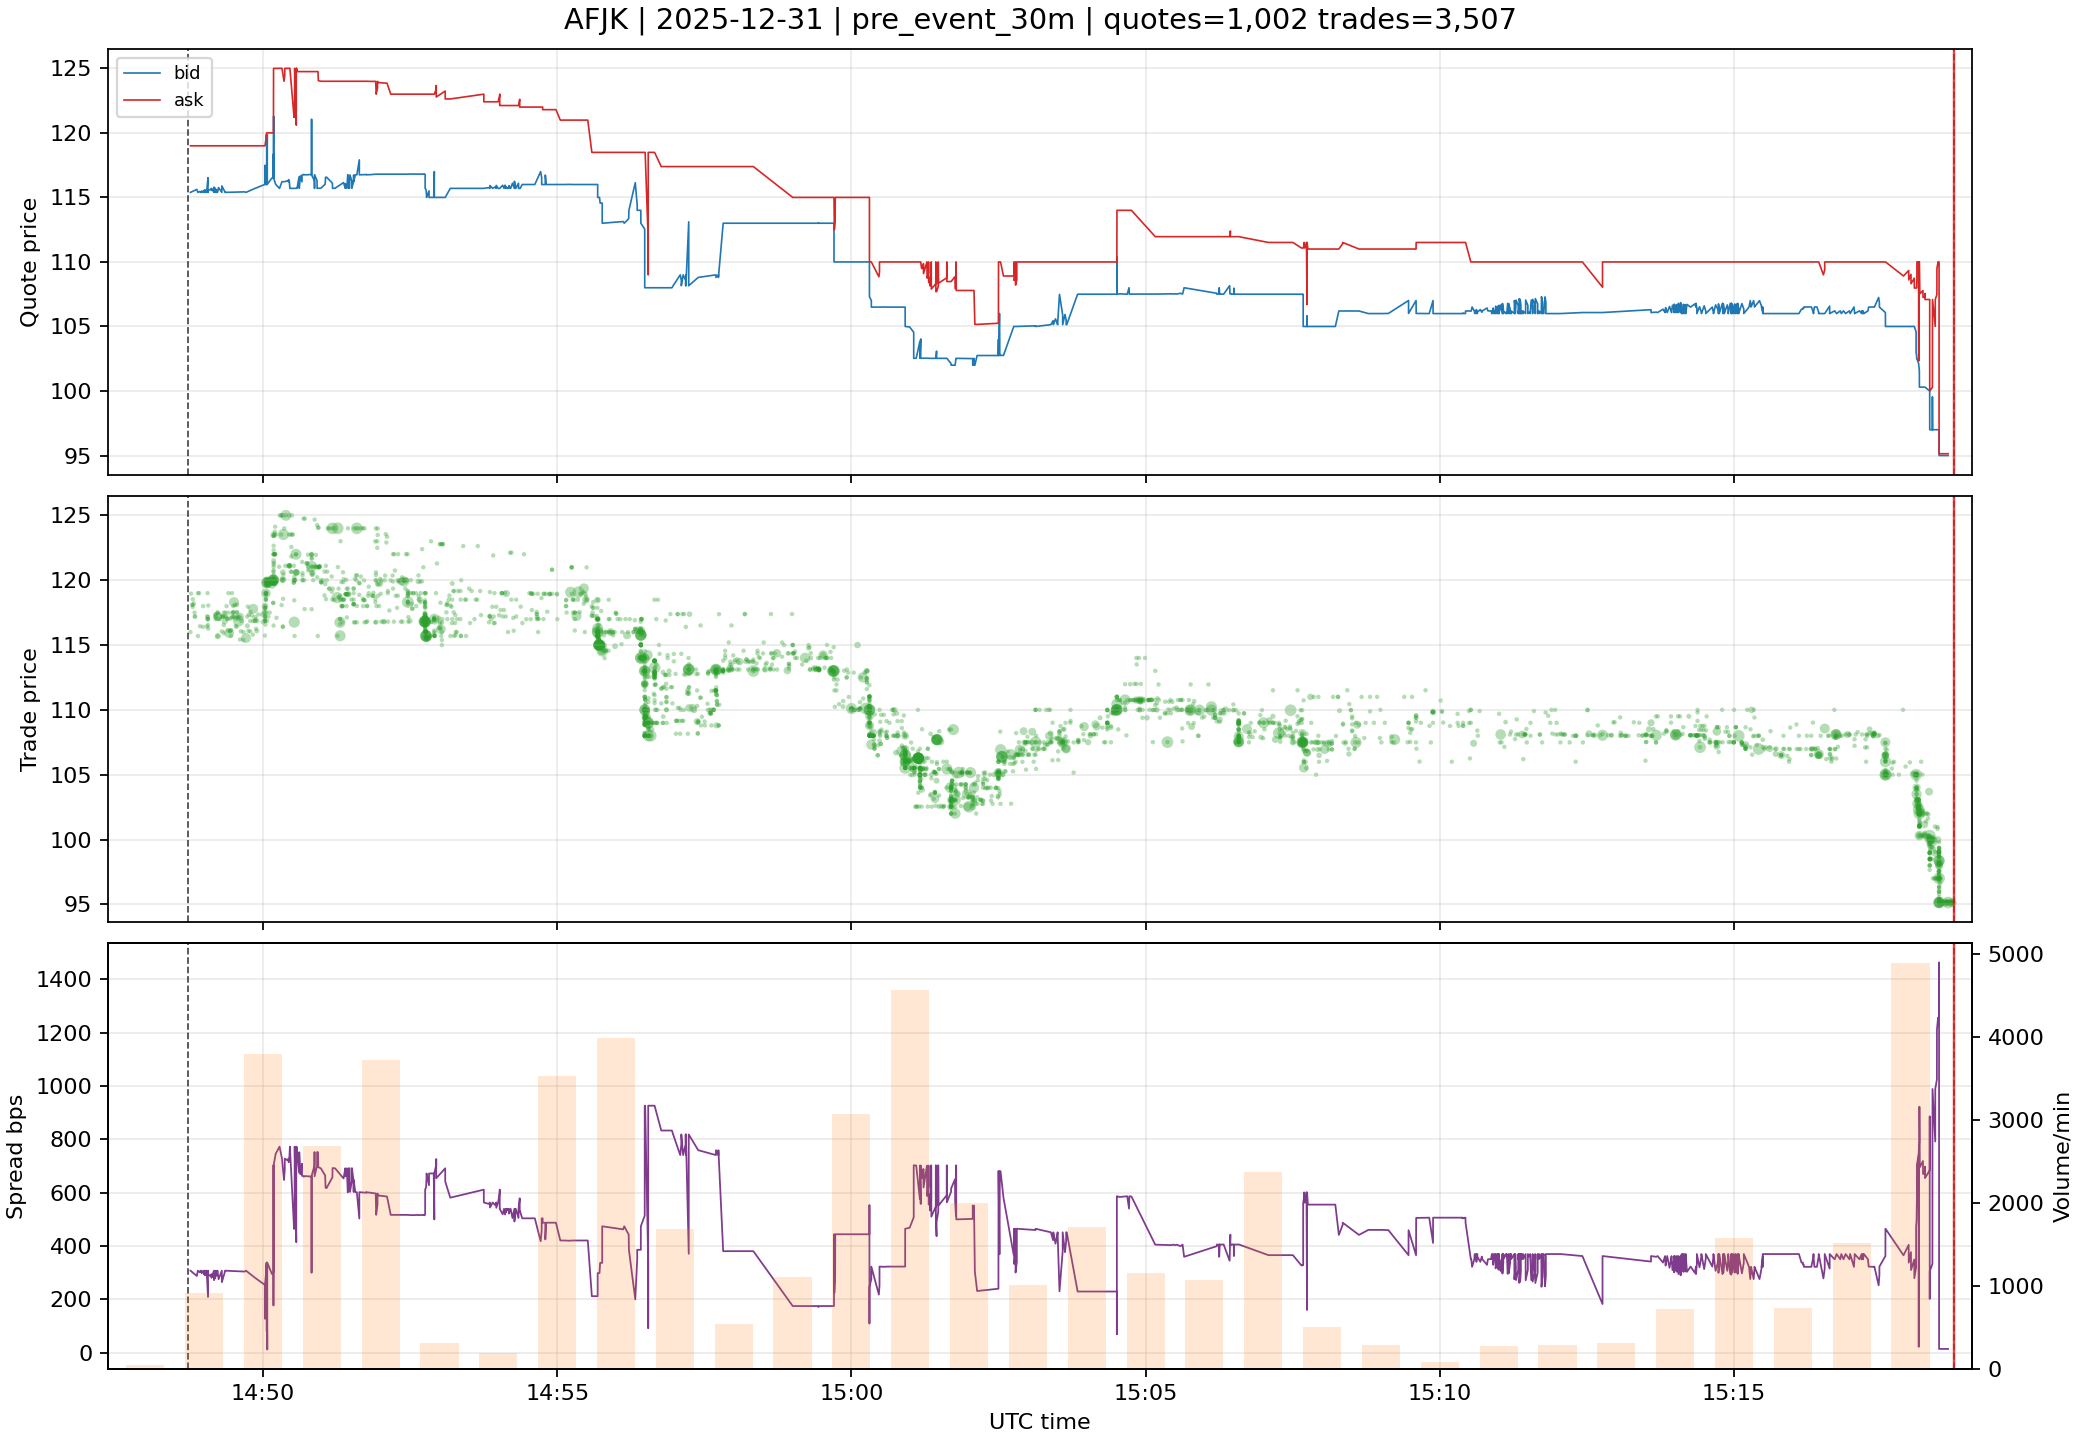

quotes=1,002, trades=3,507, median_spread_bps=403.66, p90_spread_bps=722.03, odd_lot_pct=96.44, duplicate_exact_pct=0.74, full_universe_claim=False

### Case 02 - `AFJK` `2025-12-31` `pre_event_30m`

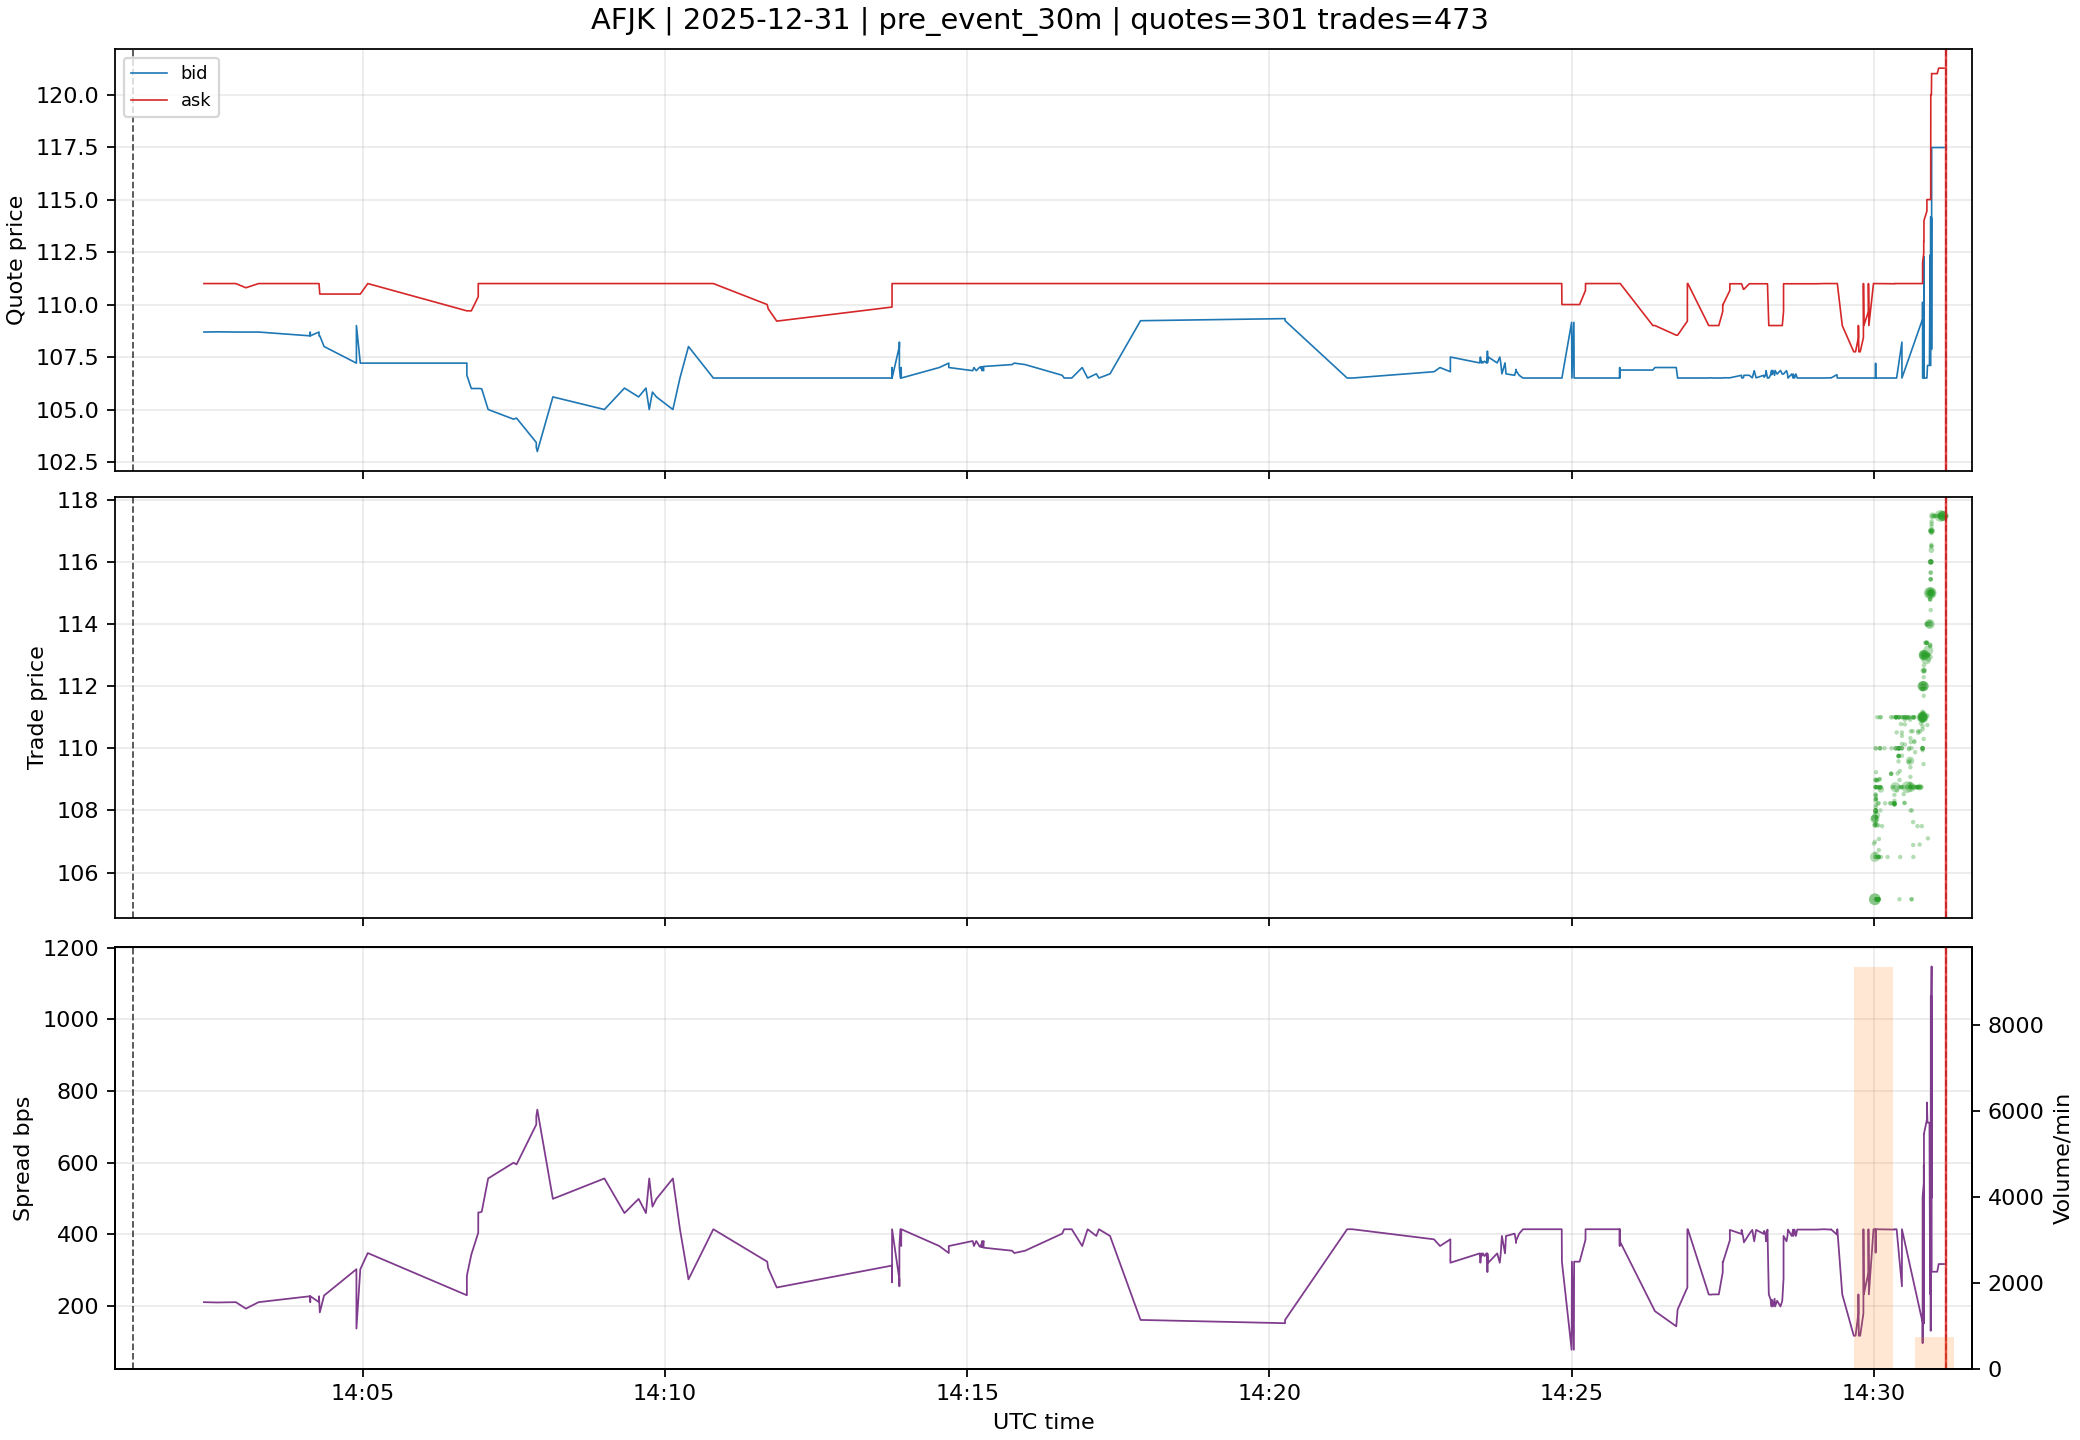

quotes=301, trades=473, median_spread_bps=366.97, p90_spread_bps=592.26, odd_lot_pct=94.93, duplicate_exact_pct=1.27, full_universe_claim=False

### Case 03 - `AFJK` `2025-12-31` `pre_event_30m`

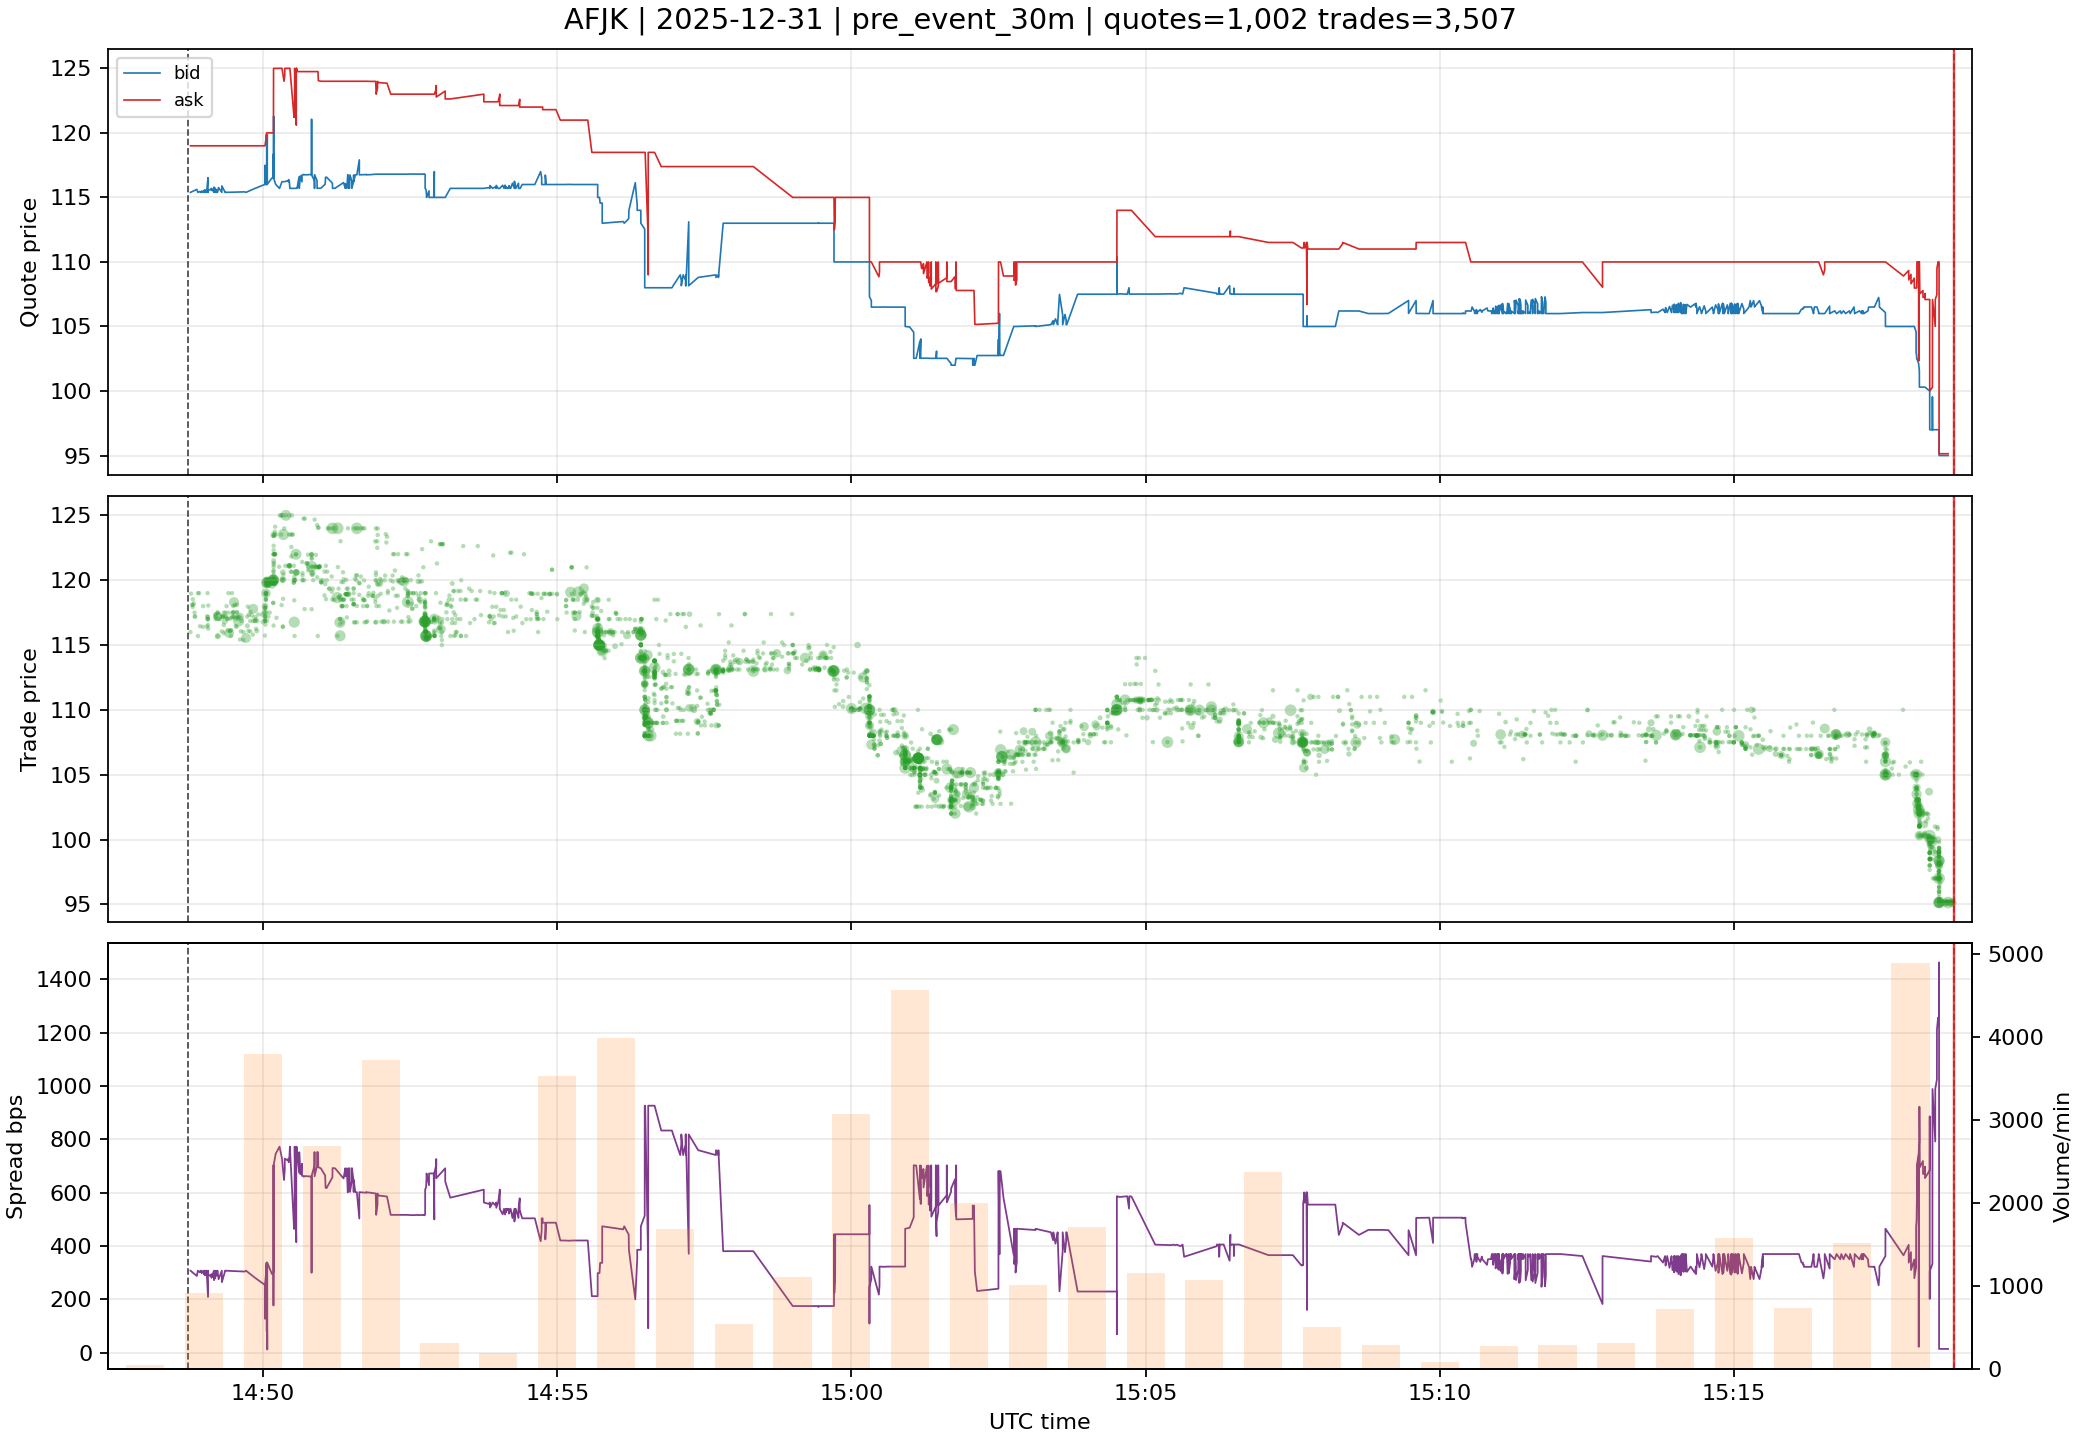

quotes=1,002, trades=3,507, median_spread_bps=403.66, p90_spread_bps=722.03, odd_lot_pct=96.44, duplicate_exact_pct=0.74, full_universe_claim=False

### Case 04 - `AFJK` `2025-12-31` `same_session_regular`

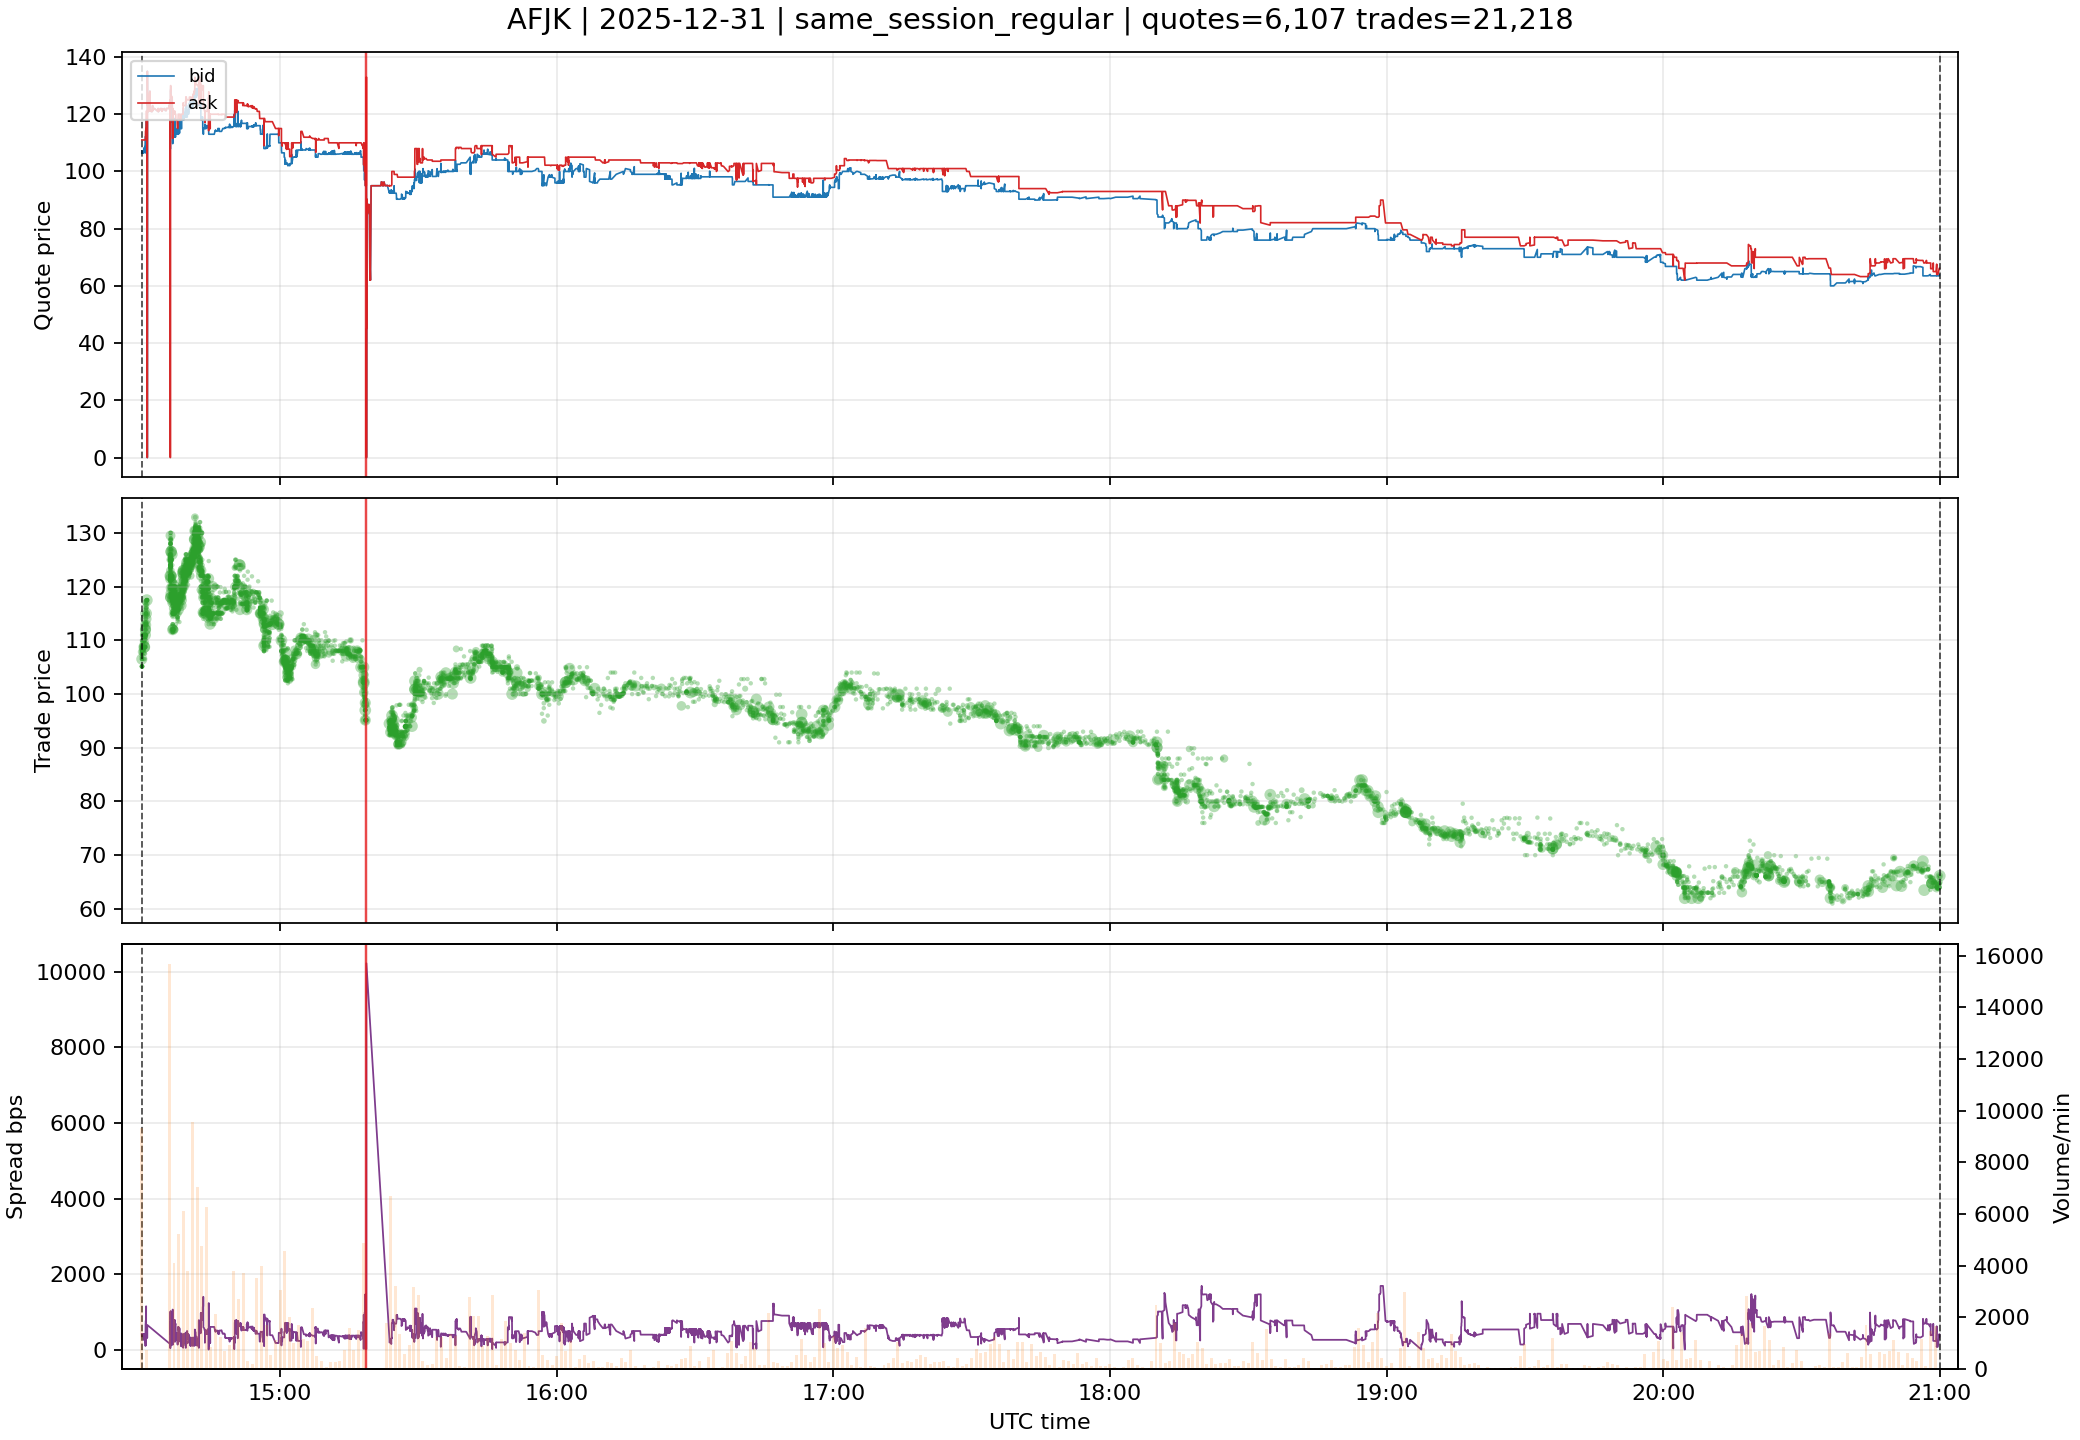

quotes=6,107, trades=21,218, median_spread_bps=497.71, p90_spread_bps=843.38, odd_lot_pct=96.06, duplicate_exact_pct=0.48, full_universe_claim=False

### Case 05 - `AFJK` `2025-12-31` `same_session_regular`

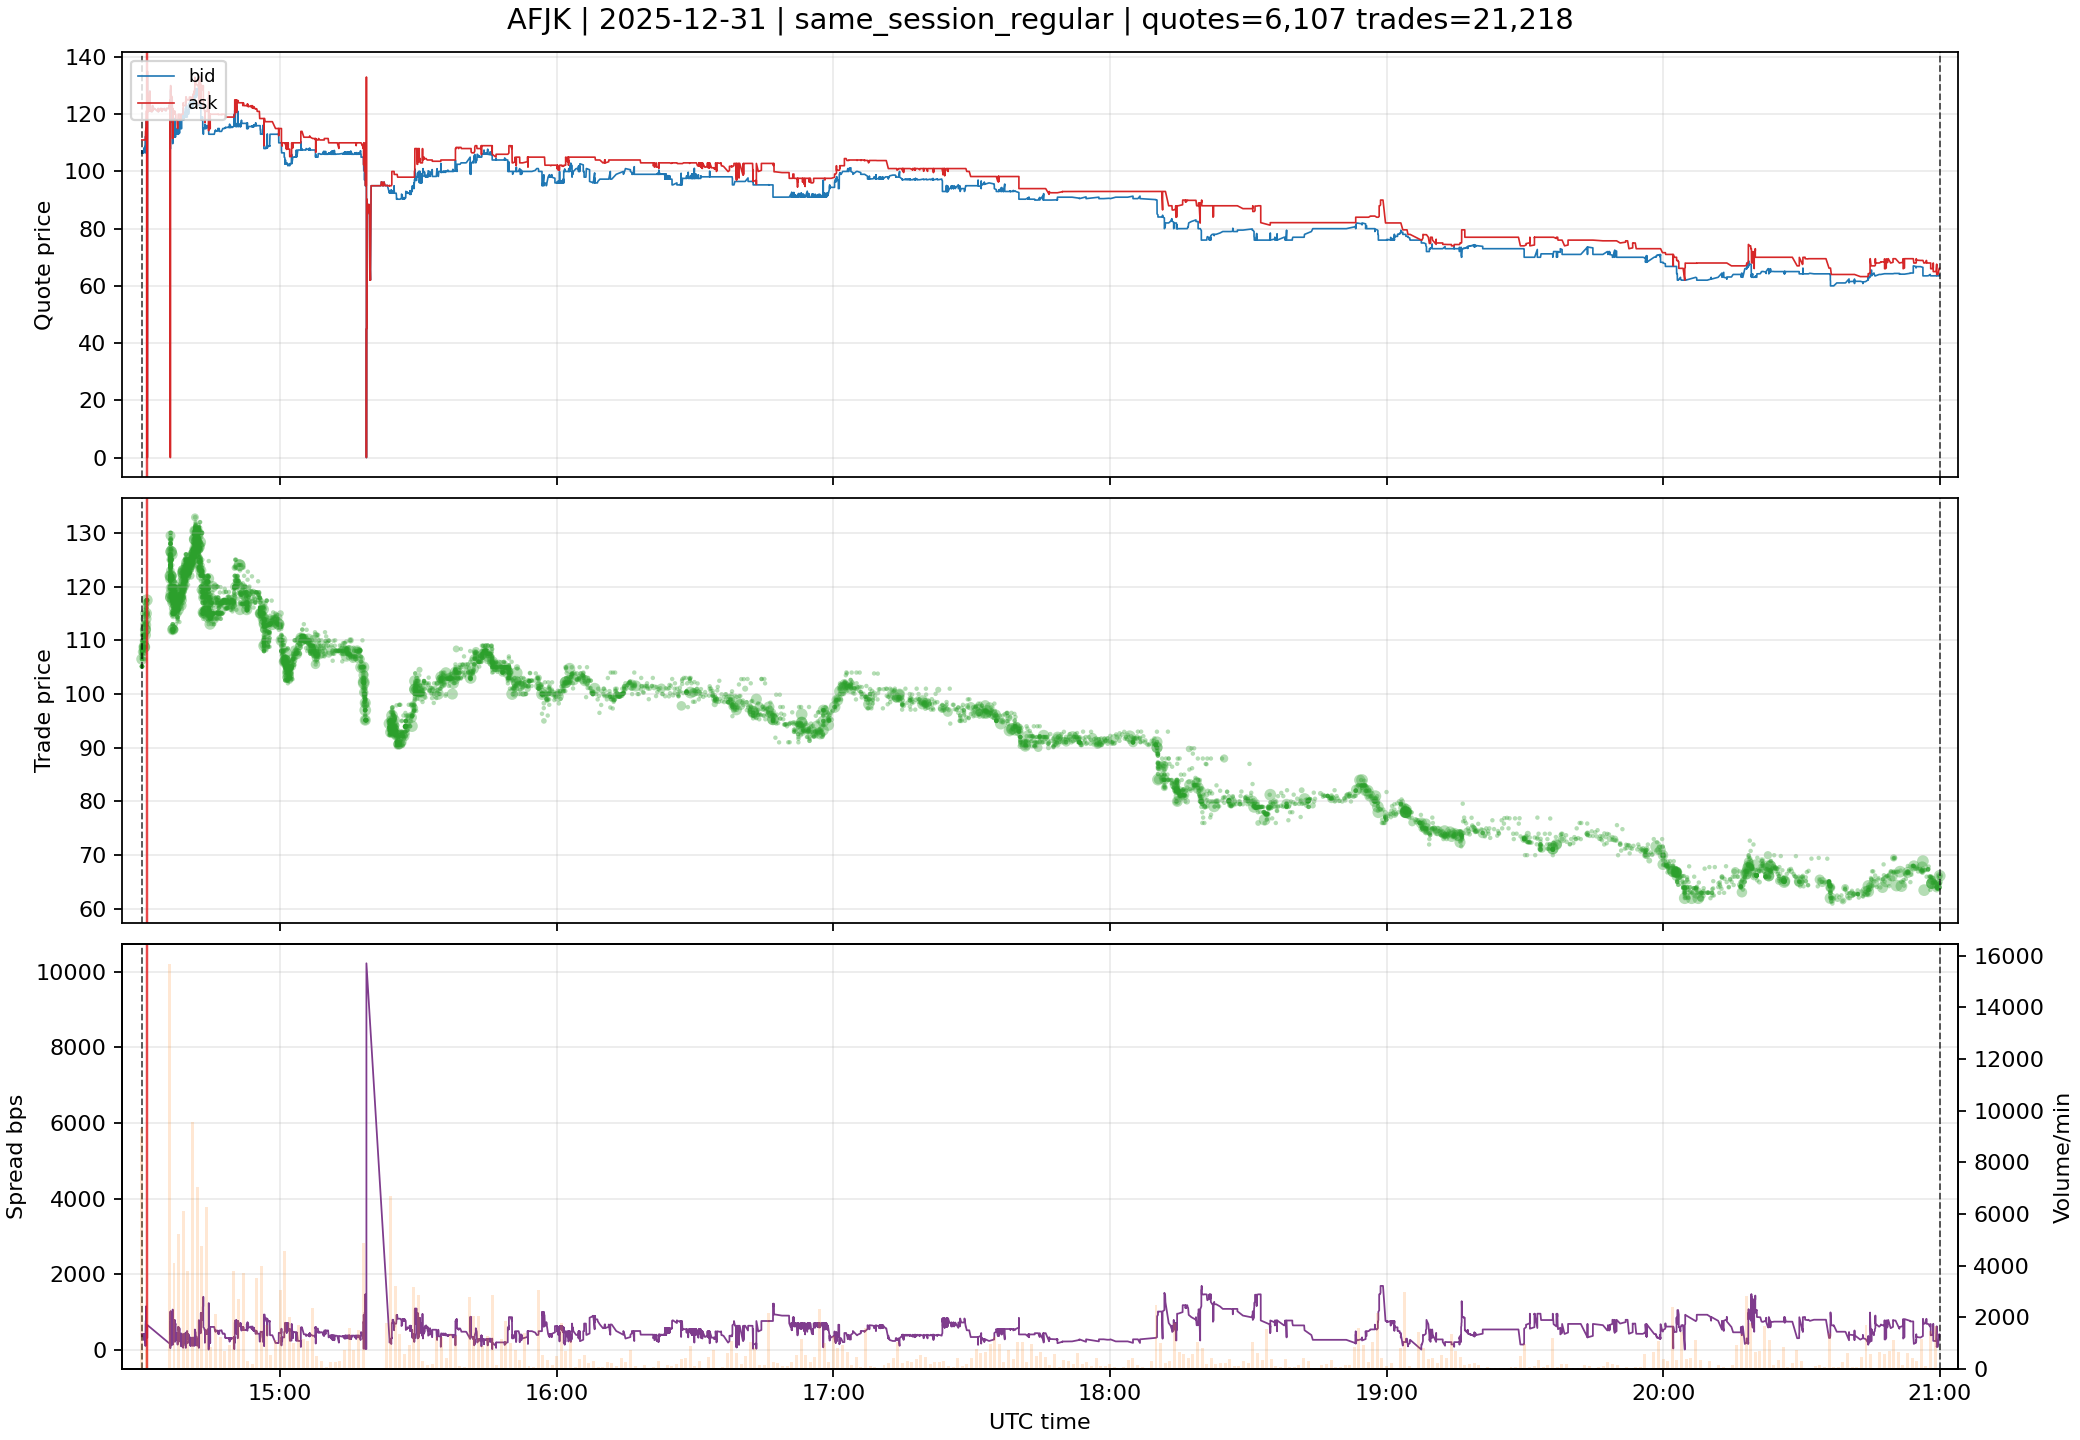

quotes=6,107, trades=21,218, median_spread_bps=497.71, p90_spread_bps=843.38, odd_lot_pct=96.06, duplicate_exact_pct=0.48, full_universe_claim=False

### Case 06 - `AFJK` `2025-12-31` `same_session_regular`

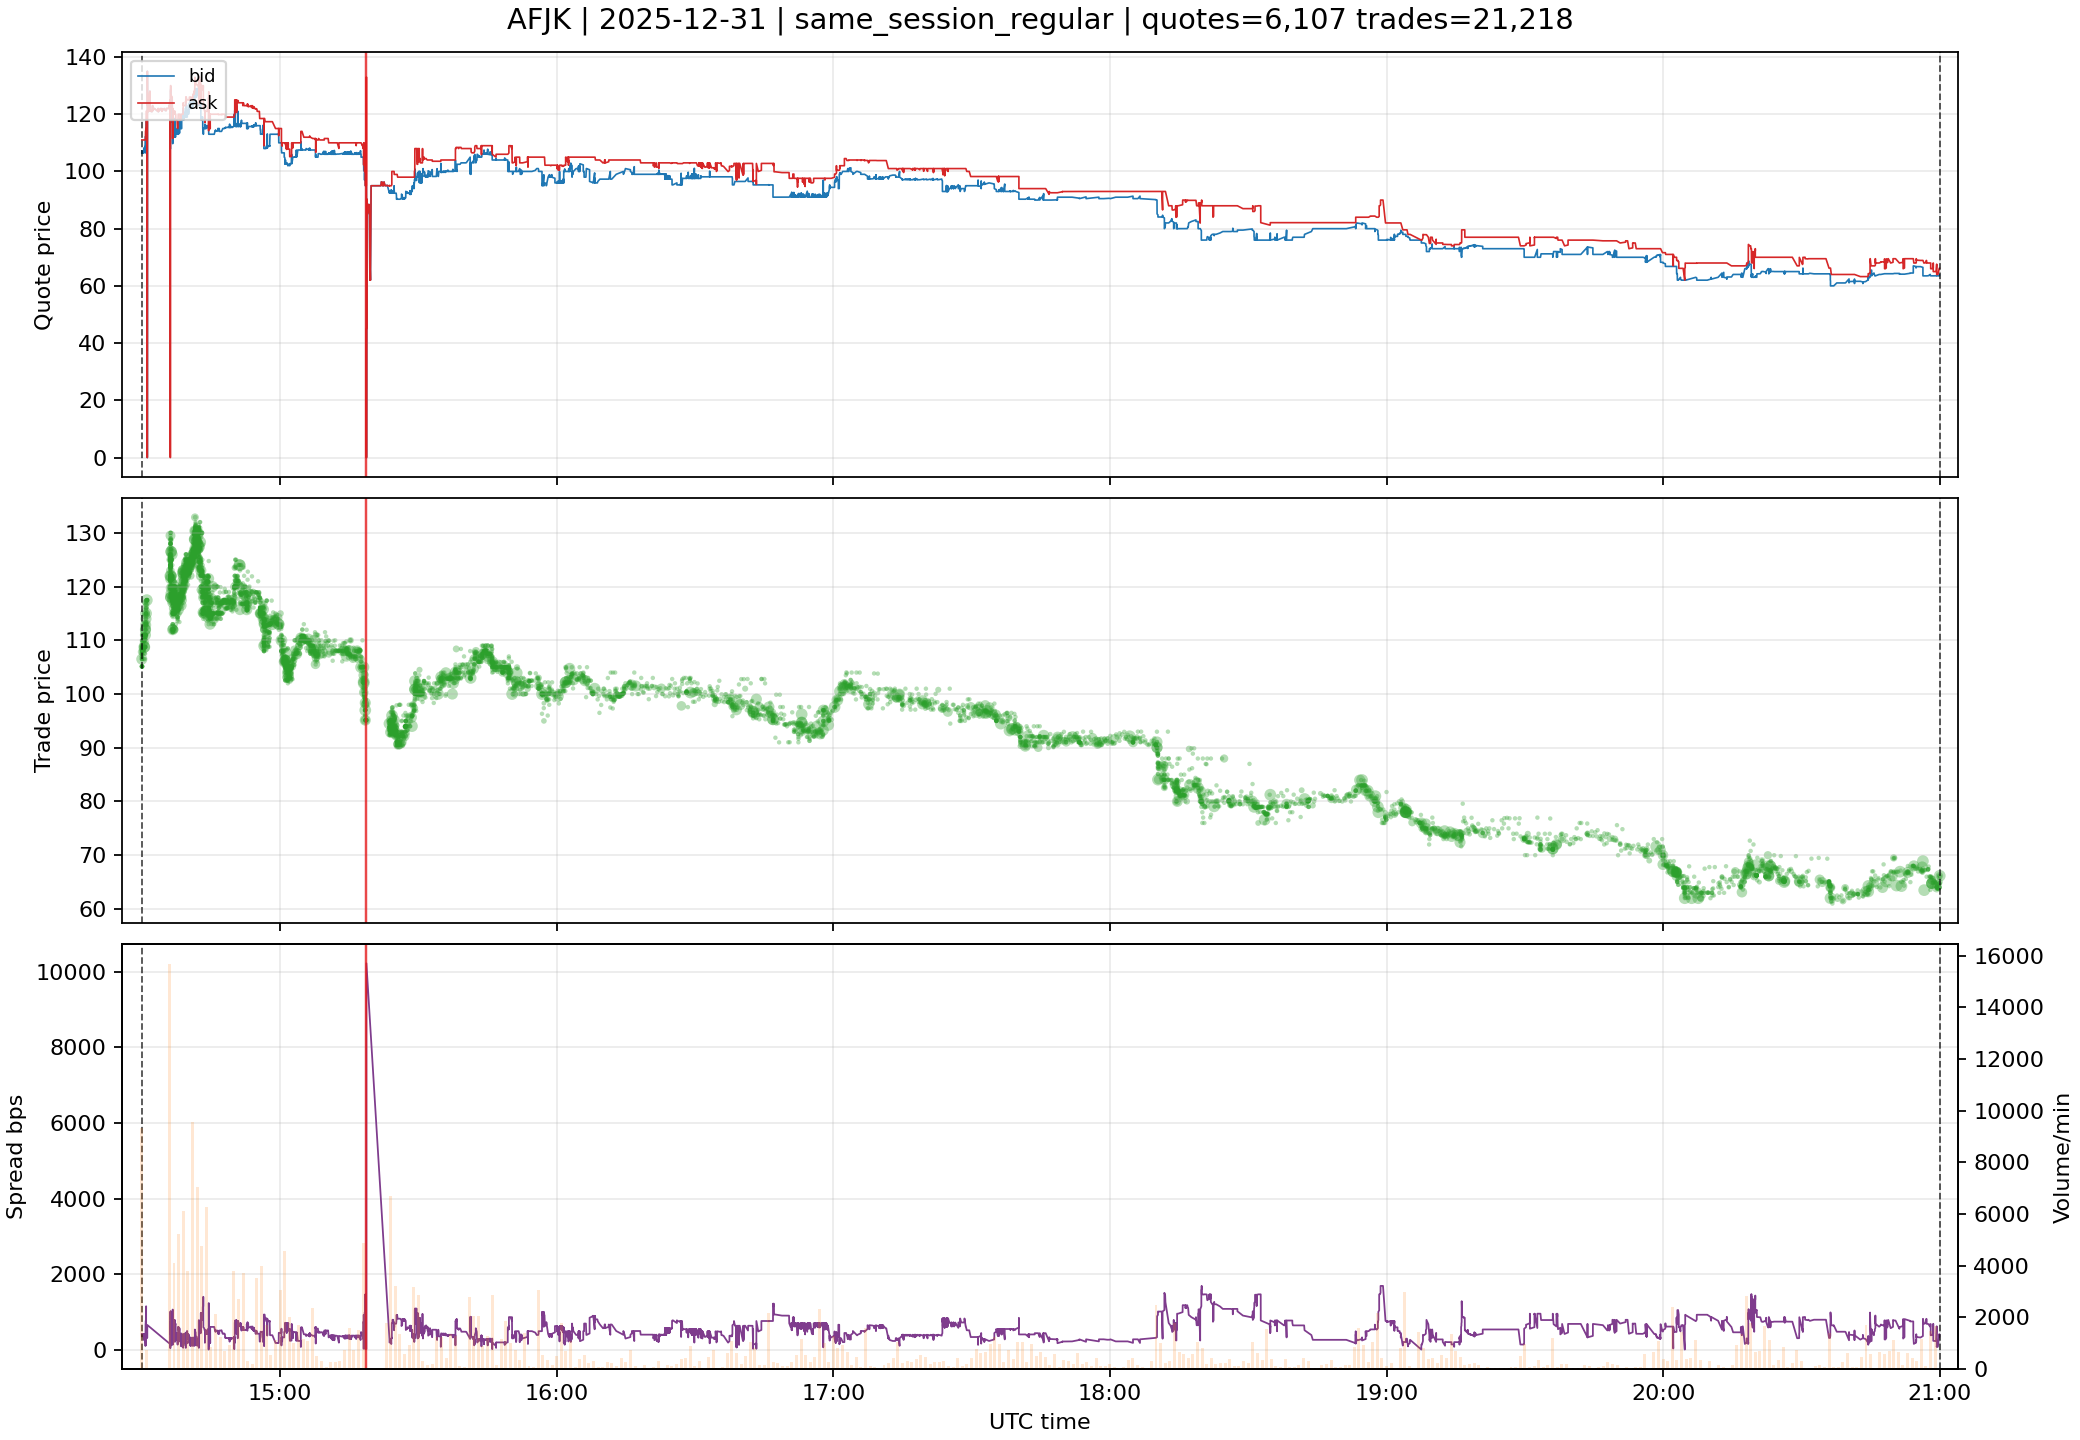

quotes=6,107, trades=21,218, median_spread_bps=497.71, p90_spread_bps=843.38, odd_lot_pct=96.06, duplicate_exact_pct=0.48, full_universe_claim=False

In [4]:
for case in manifest['cases']:
    display(Markdown(f"### Case {case['case_index']:02d} - `{case['ticker']}` `{case['session_date']}` `{case['window_role']}`"))
    display(Image(filename=case['image_path']))
    display(Markdown(
        f"quotes={case['quotes_rows']:,}, trades={case['trades_rows']:,}, "
        f"median_spread_bps={case['quotes_spread_bps_median']:.2f}, "
        f"p90_spread_bps={case['quotes_spread_bps_p90']:.2f}, "
        f"odd_lot_pct={case['trades_odd_lot_ratio_pct']:.2f}, "
        f"duplicate_exact_pct={case['trades_duplicate_exact_ratio_pct']:.2f}, "
        f"full_universe_claim={case['full_universe_claim']}"
    ))


## 4. Institutional Readout

Abrir el markdown institucional para la version auditable:

`C:/TSIS_Data/01_TSIS_DATA_FOUNDATION/01_foundations/inspection_dossiers/microstructure_features/microstructure_candidate_visual_readout_v0_1.md`


In [5]:
print(readout_path)
print("\n".join(readout_path.read_text(encoding='utf-8').splitlines()[:30]))


C:\TSIS_Data\01_TSIS_DATA_FOUNDATION\01_foundations\inspection_dossiers\microstructure_features\microstructure_candidate_visual_readout_v0_1.md
# Microstructure Candidate Visual Readout v0.1

## Scope

This readout is visual/forensic evidence for the 6-row `microstructure_features_table_v0_2_candidate` smoke artifact.

It does not promote a new official dataset and it does not claim full-universe microstructure coverage.

```text
candidate_dir = C:\TSIS_Data\tests\test_runs\2026-06-27\data_foundation_outputs_microstructure_candidate_window_manifest_v0_1\artifacts\microstructure_features_table_v0_2_candidate_output\microstructure_features_table_v0_2_candidate
window_manifest = C:\TSIS_Data\tests\test_runs\2026-06-27\data_foundation_outputs_microstructure_candidate_window_manifest_v0_1\artifacts\microstructure_candidate_materializer_manifest\microstructure_features_table_v0_2_candidate_window_manifest_v0_1.csv
case_count = 6
official_dataset_created = false
full_universe_claim = false
``